# 03 · Normalisation

Steps 15 to 19 — the last of Stage 1. Chapter 02 decided what to throw away; this one
makes what is left **comparable**, and then packs it into the single object every
chapter after this one opens.

| | |
|---|---|
| **Step 15** | Are intensities comparable across rounds? |
| **Step 16** | Is any condition an outlier? |
| **Step 17** | Normalise to the controls |
| **Step 18** | Check a known answer |
| **Step 19** | Assemble the clean object |

Steps 15 and 16 are the same kind of move: **find a reason the numbers might not mean
what they appear to**, and settle it before analysing them.

In [1]:
import sys
from datetime import date
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import analysis, plotting
from mcs2026.config import H5AD_SLIM, LAYOUT_XLSX

plotting.set_style()
pd.set_option("display.width", 140)

clean = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"))
print(f"{clean.n_obs:,} cells x {clean.n_vars:,} features, "
      f"{clean.obs.well.nunique()} wells")

65,349 cells x 2,587 features, 223 wells


## Step 15 · Are intensities comparable across rounds?

[Step 9](01_columns_to_markers.ipynb) found that DAPI — the same stain, on the same
nuclei, every round — moves by more than an order of magnitude across the experiment.
Here is what that means for the markers.

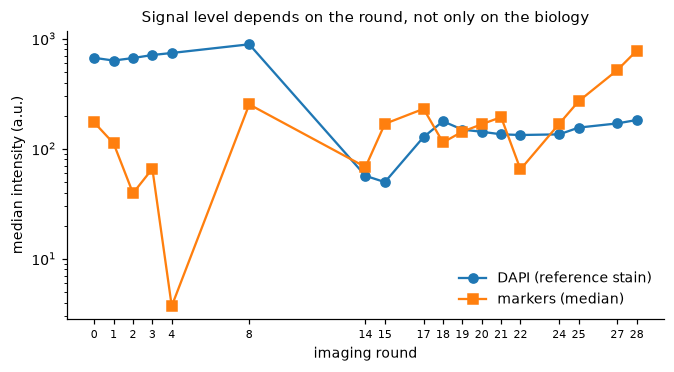

In [2]:
dapi_columns = clean.var.loc[
    clean.var.index[(clean.var.channel == "DAPI") & (clean.var.statistic == "mean_intensity")]
].sort_values("round").index

dapi = pd.Series(
    np.median(np.asarray(clean[:, list(dapi_columns)].X), axis=0),
    index=clean.var.loc[dapi_columns, "round"].astype(int).values, name="median DAPI",
)

marker_cols = analysis.marker_columns(clean.var)
marker_median = pd.Series(
    np.median(np.asarray(clean[:, marker_cols].X), axis=0),
    index=clean.var.loc[marker_cols, "round"].astype(int).values,
).groupby(level=0).median()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(dapi.index, dapi.values, marker="o", label="DAPI (reference stain)")
ax.plot(marker_median.index, marker_median.values, marker="s", label="markers (median)")
ax.set(xlabel="imaging round", ylabel="median intensity (a.u.)", yscale="log",
       title="Signal level depends on the round, not only on the biology")
ax.set_xticks(dapi.index)
ax.tick_params(axis="x", labelsize=7)
ax.legend()

The nuclei did not change between rounds. The measurement did.

So a heatmap that puts a round-2 marker next to a round-27 marker, or a PCA over the
whole panel, is partly ranking markers by *when they were imaged*. Two things follow:

- **compare a marker to itself across conditions**, never one marker's absolute level to
  another's;
- **centre every marker on its own controls**, which is Step 17.

## Step 16 · Is any condition an outlier?

Before normalising, look at the conditions as a whole. Unsupervised methods are
obedient: hand them one sample that differs from everything else and they will spend
their first component describing it.

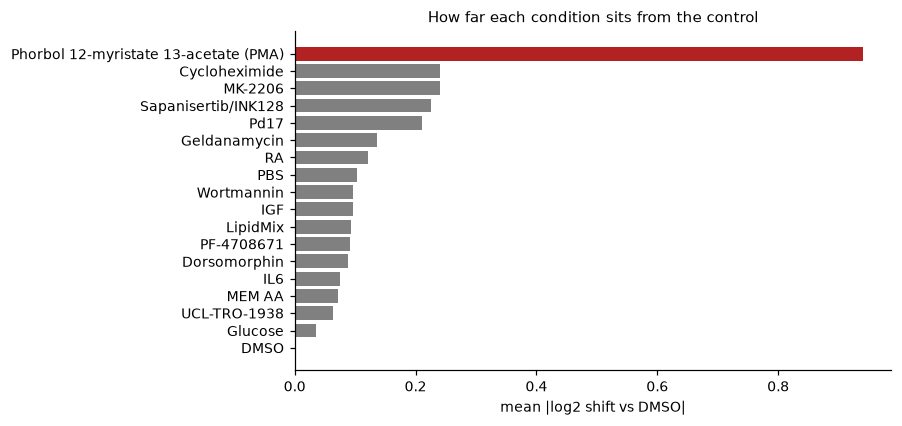

In [3]:
wells = analysis.by_well(clean, marker_cols, name_by="marker")
names = [clean.var.loc[c, "marker"] for c in marker_cols]

logged = np.log2(wells[names] + 1)
centred = logged - logged[wells.condition == "DMSO"].mean()
spread = centred.groupby(wells.condition).mean().abs().mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colours = ["firebrick" if v == spread.index[0] else "0.5" for v in spread.index]
ax.barh(range(len(spread)), spread.values, color=colours)
ax.set(yticks=range(len(spread)), yticklabels=spread.index,
       xlabel="mean |log2 shift vs DMSO|", title="How far each condition sits from the control")
ax.invert_yaxis()

In [4]:
spread.head(4).round(3)

condition
Phorbol 12-myristate 13-acetate (PMA)    0.940
Cycloheximide                            0.240
MK-2206                                  0.240
Sapanisertib/INK128                      0.225
dtype: float32

**PMA moves every marker, by a lot** — several times further than anything else. That is
not a pathway response, it is a different cell state. Phorbol esters drive naive human ES
cells out of pluripotency, so a wholesale change is biologically reasonable; it is still
an outlier statistically.

:::{important}
This is a decision, and it should be a conscious one:

- **keep PMA** and it dominates the first component of every embedding, so the plot
  describes PMA-vs-everything rather than the structure among the other seventeen;
- **drop PMA** and you lose a real, strong biological effect;
- **flag it and analyse it knowingly**, which is what this course does.

What you must not do is leave it in silently and then interpret component 1 as if it
were about subtle signaling differences.
:::

In [5]:
clean.obs["is_outlier_condition"] = clean.obs.condition.astype(str).eq(
    "Phorbol 12-myristate 13-acetate (PMA)"
)
print(f"  flagged {clean.obs.is_outlier_condition.sum():,} cells in "
      f"{clean.obs.loc[clean.obs.is_outlier_condition, 'well'].nunique()} wells")

  flagged 3,557 cells in 12 wells


## Step 17 · Set the origin and the unit

Normalising is **two** decisions, not one, and running them together is how a time course
gets thrown away. The **origin** says what counts as zero. The **unit** says what counts
as one. They answer different questions, they can be estimated from different cells, and
here they have to be.

### First, `log2`

Intensities are multiplicative and heavily right-skewed. A doubling should look the same
whether it is 100→200 or 1000→2000. After `log2` it does.

### The origin — the controls at the *first* timepoint

The obvious move is to centre each timepoint on its own control wells. It is also the one
mistake this step exists to prevent.

**A moving origin cannot show movement.** Centre every timepoint on its own controls and
the control sits at zero at 36 h, zero at 60 h and zero at 84 h — not because nothing
happened to it, but because you defined it that way. What survives is "different from the
control *at the same moment*", which is a fair question and not the one a time course
asks. The controls' own development — the thing that 36 to 84 hours was for — would be
gone before the first plot.

So the origin is fixed **once**, from the control cells at the first timepoint. Zero means
*an untreated cell at the start of the experiment*, and every other cell — control or
treated, early or late — is measured from that one point.

**Does one origin still remove the round-to-round drift from Step 15?** It does, and the
plate layout is the reason. All four timepoints sit on the **same plate** and go through
the same eighteen rounds: the cells were treated at staggered times and fixed together, so
p-S6 in a 36 h well and p-S6 in an 84 h well were stained in the same round, in the same
buffer, on the same day.

The drift is therefore **one number per marker, shared by every timepoint**, and a single
subtraction removes it everywhere. A per-timepoint origin removes that same constant and
takes the biology with it. Same artefact, same cure — and an entire experiment's
difference in what is left standing.

### The unit — the spread of the controls, across the whole plate

The unit wants as many control cells as it can get, so that it is stable. But "the spread
of all control cells pooled" is too much: pooled naively it would also contain the drift
across time and the gap between the two vehicles, and both would be counted as noise.
Anything later measured in a unit that wide is quietly shrunk.

So take each control cell's deviation **from the median of its own vehicle at its own
timepoint**, and pool those instead. The unit becomes the spread of a control cell about
its own group: plate-wide and stable, without the two things that are not spread.

### Median, not mean

Single-cell intensity distributions have long right tails, and debris, doublets and dying
cells live in them. A mean follows them; a median does not. So the origin is a median, and
the unit is 1.4826 × the median absolute deviation — the MAD rescaled so that, for normal
data, one unit means the same as one standard deviation.

### Both vehicles

DMSO and PBS are both controls, and between them they cover **seven plate rows** rather
than four. They are not interchangeable, though:
[chapter 07](../2_controls/07_umap.ipynb) finds 11 of the 38 markers separating them by
more than a control SD. So each vehicle contributes its own median, the origin is the
average of the two, and the gap between them never gets into the unit.

One recipe, applied once, to cells:

In [ ]:
values = analysis.normalise_cells(clean, marker_cols)
print(f"  {values.shape[0]:,} cells x {values.shape[1]} markers, {values.dtype}")
print(f"  origin: {', '.join(analysis.CONTROLS)} cells at {min(clean.obs.timepoint_h.astype(int))} h")

### The check, which is no longer a tautology

The old check asked whether the controls sat at 0 with spread 1 *at every timepoint*.
They did — by construction, whatever the data said. Ask instead what this recipe actually
promises: zero at the start, free to move afterwards.

In [ ]:
controls = clean.obs.condition.astype(str).isin(analysis.CONTROLS).values
timepoint = clean.obs.timepoint_h.astype(int).values
pd.DataFrame(
    [{"timepoint": t,
      "control cells": int((controls & (timepoint == t)).sum()),
      "median |shift| across markers":
          round(float(np.abs(np.median(values[controls & (timepoint == t)], axis=0)).mean()), 3),
      "spread": round(float(values[controls & (timepoint == t)].std(ddof=1)), 3)}
     for t in sorted(set(timepoint))]
).set_index("timepoint")

**The first row is zero because that is where the origin was put.** The rows under it are
not constrained by anything — they are the controls' own development over the next two
days, in control-cell SDs, and they are exactly what the per-timepoint recipe used to set
to zero. The spread column stays near 1 at every timepoint, which is the unit doing its
job.

If those later rows had come back near zero as well, that would be a real result: the
controls did not move. The difference is that now the data gets to say so.

### The well table is not a second normalisation

Every statistical test in Part 3 runs on **well means**, because the well is what was
independently treated. That table is not normalised again — it is these same numbers,
averaged. Normalise once, to cells; everything else is an average of the result.

In [ ]:
cleaned = ad.AnnData(X=values, obs=clean.obs.copy(),
                     var=clean.var.loc[marker_cols].copy())
# The long channel-and-round name was useful while decoding; from here the marker is the
# name you want, and `var["column"]` keeps the original so nothing is lost.
cleaned.var["column"] = marker_cols
cleaned.var_names = names

normalised = analysis.by_well(cleaned)
normalised.iloc[:4, :7].round(2)

## Step 18 · Check a known answer

The compounds were chosen to hit specific processes, so there is a prediction to test.
**Sapanisertib/INK128 inhibits mTOR**; mTORC1 activates S6 kinase, which phosphorylates
ribosomal protein S6. So INK128 should lower **p-S6**.

In [ ]:
analysis.compare_to_control(normalised, "p-S6", "Sapanisertib/INK128")

In [ ]:
analysis.compare_to_control(normalised, "p-S6", "MK-2206")

Both inhibitors lower p-S6 by several control SDs, most strongly at 36 h and weakening
steadily after — by 84 h MK-2206 has no measurable effect at all, and INK128's is a
fraction of what it was. The compound is used up, or the cells adapt. A real result, with
the sign the pathway predicts. **The normalisation works.**

:::{warning}
**Read the p-values, not the stars.** Every significant row reads `0.0357`, and that is
not a coincidence: with 3 treated wells and 5 control wells there are
$\binom{8}{3} = 56$ rank orderings, so the smallest two-sided p-value a Mann-Whitney test
can *ever* return here is $2/56 = 0.0357$.

No effect size, however enormous, produces a smaller one. The p-value has hit the floor
set by the number of wells — the same lesson as the $\sqrt{n-1}$ ceiling in
[Step 12](02_quality_control.ipynb), in a different disguise. `analysis.rank_effects`
reports that floor alongside every p-value for exactly this reason.
:::

### The one that does not work

The obvious readout for an AKT inhibitor is phospho-AKT itself. Try it.

In [ ]:
analysis.compare_to_control(normalised, "p-AKT", "MK-2206")

Compare that with the p-S6 table above. p-S6 falls at every early timepoint, by a lot,
in the same direction. p-AKT does nothing of the kind: it drifts down at 36 h, **up** at
48 h, down again at 60 h, and vanishes at 84 h. One row happens to clear the p-value
floor, but a signal that changes sign between timepoints is not a signal.

This is not a failure of the normalisation, and it is worth understanding rather than
explaining away:

- **Pathway feedback.** Inhibiting mTORC1 relieves a negative feedback loop onto the
  receptor, which *raises* AKT phosphorylation. Inhibitor and feedback partly cancel.
- **Where the antibody sits.** p-AKT was imaged in round 24, near the end of eighteen
  elution cycles. Phospho-epitopes are the most fragile thing in a 4i panel.
- **Downstream integrates.** p-S6 reflects sustained pathway output; a single
  phospho-site is a snapshot of a fast equilibrium.

The pathway *is* visible — one step sideways:

In [ ]:
for condition in ["MK-2206", "Wortmannin", "Sapanisertib/INK128"]:
    shifts = analysis.compare_to_control(normalised, "Foxo1", condition)["shift"]
    print(f"  Foxo1 vs {condition:22s} {list(shifts)}  all negative: {bool((shifts < 0).all())}")

**Foxo1 falls for all three inhibitors, at every timepoint.** FoxO transcription factors
are direct AKT substrates. The pathway is there; it is simply not where you first looked.

## Step 19 · Assemble the clean object

Everything Stage 1 established is currently scattered: the values are in one file, the
decoder in a `var` table, the dropped wells in a `uns` entry, and the normalisation only
exists as a well-level DataFrame that lives in this notebook's memory.

This step puts it in one object, so that every chapter after this one begins with a
single `read_h5ad` and no set-up.

```{image} ../../images/clean_object_light.svg
:class: only-light
:alt: The clean AnnData: X holding normalised values, a raw layer, an annotated var table, a tidy obs table, and provenance in uns.
```
```{image} ../../images/clean_object_dark.svg
:class: only-dark
:alt: The clean AnnData: X holding normalised values, a raw layer, an annotated var table, a tidy obs table, and provenance in uns.
```

### Which columns go in it?

2,587 features survived Step 9. The object carries **38** of them — one mean intensity per
antibody per cell. That is a large cut and it needs an argument, not a preference.

In [ ]:
counts = clean.var.family.value_counts()
pd.DataFrame({"columns": counts, "% of the table": (100 * counts / counts.sum()).round(1)})

**A feature set votes by column count.** Texture is most of what survived, so it decides
most of anything computed from all of it. That is a claim, so measure it — cheaply, at the
well level, where the whole table is 223 rows.

In [ ]:
everything = clean.var.index.tolist()
well_wide = analysis.by_well(clean, everything)
# abs() because Morphology_orientation is an angle and reaches -1.57; log2 of that
# would be NaN. It is the one non-positive column in the table.
logged = np.log2(np.abs(well_wide[everything]) + 1)

reference = logged[(well_wide.condition == "DMSO").values]
# A column with no spread across the control wells carries no information here, and
# dividing by its zero would give infinities that fillna does not catch.
spread = reference.std().replace(0, np.nan)
scaled = (((logged - reference.mean()) / spread)
          .replace([np.inf, -np.inf], np.nan).fillna(0))

survey = ad.AnnData(scaled.to_numpy(dtype="float32"))
sc.pp.pca(survey, n_comps=2, random_state=0)
weight = (pd.Series(np.abs(survey.varm["PCs"][:, 0]), index=everything)
          .groupby(clean.var.family, observed=True).sum())
pd.DataFrame({
    "% of columns": (100 * counts / counts.sum()).round(1),
    "% of PC1's loading": (100 * weight / weight.sum()).round(1),
}).sort_values("% of columns", ascending=False)

**Read the two columns against each other.** Each family contributes to the first component
in almost exactly the proportion of columns it has — not in proportion to how much it
knows. Feed a method everything and you have not asked it an open question; you have voted
for texture 2,262 times.

**And most of those columns repeat each other.** Each marker carries 58 texture features.
How many independent numbers is that really?

In [ ]:
one_marker = clean.var.index[(clean.var.family == "Texture") & (clean.var.marker == "LAMP1")]
block = ad.AnnData(scaled[list(one_marker)].to_numpy(dtype="float32"))
sc.pp.pca(block, n_comps=min(block.n_vars, block.n_obs) - 1, random_state=0)
spectrum = block.uns["pca"]["variance_ratio"]

correlation = scaled[list(one_marker)].corr().abs().values
np.fill_diagonal(correlation, np.nan)
print(f"  LAMP1 has {len(one_marker)} texture columns")
print(f"  median |correlation| between them: {np.nanmedian(correlation):.2f}")
print(f"  components reaching 90% of their variance: {(np.cumsum(spectrum) < 0.9).sum() + 1}")

Fifty-eight columns, and single figures of real dimension between them. The block
is wide, not deep.

:::{important}
**What this gives up, stated plainly.** Texture is not noise. It measures something the
mean cannot — *how* a protein is arranged rather than how much of it there is — and for
several markers on this plate that is where the effect lives: the mean barely moves while
the texture of the same marker shifts by several control SDs. A compound that redistributes
a protein without changing its abundance is invisible to every number in this object.

This course asks the first question. "How much of each protein is in this cell" is
answerable with 38 interpretable numbers, every one of which reads back to an antibody, and
a component you cannot name is a component you cannot report.

The wide table stays on disk as `mcs2026_slim.h5ad` and the door is open. Three things
will bite you when you walk through it: `Morphology_orientation` is an angle in radians, so
it has no mean and no meaningful z-score; `Population_mean_distance_nn_50` and `_100`
already contain NaNs; and Haralick correlations are roughly symmetric while Laws energies
are skewed like intensities, so no single transform is right for all of them.
:::

In [ ]:
marker_cols = analysis.marker_columns(clean.var)
marker_names = clean.var.loc[marker_cols, "marker"].tolist()
print(f"{len(marker_cols)} markers, one column each")
print(f"  {', '.join(marker_names[:10])} …")

### Build it

`X` is already normalised — that happened once, in Step 17 — so the object is assembled
around values that exist. Five slots, each with a job:

| slot | what goes in it |
|---|---|
| `X` | the normalised values — control-cell SDs from an origin at the first timepoint |
| `layers["raw"]` | the intensities as measured, so nothing is thrown away |
| `var` | marker, channel, round, family, theme, thresholds — the decoder from Step 7 |
| `obs` | well, row, column, condition, timepoint, replicate, area, DAPI |
| `uns["provenance"]` | what was dropped, why, and how the numbers were made |

In [ ]:
cleaned.layers["raw"] = np.asarray(clean[:, marker_cols].X, dtype="float32")

**`replicate`** is the one piece of metadata the plate implies but never states: which
of the three (or five) wells of a condition × timepoint this cell came from. Every
statistical test in Part 4 counts wells, so the number is worth having explicitly.

In [ ]:
well_key = (cleaned.obs[["condition", "timepoint_h", "well"]]
            .drop_duplicates()
            .sort_values(["condition", "timepoint_h", "well"]))
well_key["replicate"] = (well_key.groupby(["condition", "timepoint_h"], observed=True)
                         .cumcount() + 1)
cleaned.obs["replicate"] = (cleaned.obs.well.astype(str)
                            .map(dict(zip(well_key.well.astype(str), well_key.replicate)))
                            .astype("int8"))
well_key.groupby("condition", observed=True).replicate.max().rename("wells per timepoint")

Two more per-cell numbers are worth carrying across. Neither is a marker — **area** is a
shape measurement and **DAPI** is the counterstain imaged in every round — so neither
belongs in `X` alongside the antibodies. But both explain things the markers cannot: how
big a cell is, and how brightly it stained overall. They go in `obs`.

In [ ]:
area_column = clean.var.index[(clean.var.family == "Morphology")
                              & (clean.var.statistic == "area")][0]
dapi_column = clean.var.index[(clean.var.channel == "DAPI")
                              & (clean.var.statistic == "mean_intensity")
                              & (clean.var["round"] == 0)][0]
cleaned.obs["area"] = np.asarray(clean[:, area_column].X).ravel()
cleaned.obs["dapi"] = np.asarray(clean[:, dapi_column].X).ravel()
cleaned.obs[["area", "dapi"]].describe().loc[["mean", "std", "min", "max"]].round(1)

### Write down what happened to it

In six months you will open this file and not remember whether the border cells came
out, or which well was dropped and why. Neither will whoever you send it to. `uns` is
where that goes.

In [ ]:
cleaned.uns["provenance"] = {
    **clean.uns.get("provenance", {}),
    "built_by": "Multicellular Systems 2026, Part 3 Stage 1, chapter 03",
    "built_on": date.today().isoformat(),
    "layout_workbook": LAYOUT_XLSX.name,
    "cells_removed": "border cells — is_border_external or is_border_internal",
    "wells_removed": "; ".join(f"{w}: {why}" for w, why in clean.uns["dropped_wells"].items()),
    "features": f"{len(marker_cols)} marker mean intensities, decoded from 4,464 raw columns",
    "X": ("log2(x + 1); origin = median of the DMSO+PBS cells at the first timepoint, "
          "unit = 1.4826 x MAD of control cells about their own vehicle x timepoint median"),
    "layers_raw": "mean intensity as measured",
    "units": "control-cell standard deviations",
}
for key, value in cleaned.uns["provenance"].items():
    print(f"  {key:18s} {value}")

### Save

In [ ]:
cleaned.write_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"), compression="gzip")
normalised.to_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cleaned

:::{tip}
**Two files, two jobs.** `mcs2026_clean.h5ad` is one row per **cell** — embeddings,
clustering, single-cell distributions. `mcs2026_wells.parquet` is one row per **well**,
already averaged — every statistical test, because the well is what was independently
treated. Reaching for the wrong one is the single most common mistake in Part 3, and
[chapter 08](../2_controls/08_cell_type_annotation.ipynb) shows what it costs.
:::

## Stage 1 complete

| | |
|---|---|
| **started with** | 733,556 × 4,464, `var` empty, 13.1 GB |
| **removed** | border cells (~11%), one well, redundant DAPI and duplicated structural blocks |
| **ended with** | `mcs2026_clean.h5ad` — every surviving cell × 38 named markers |
| **units** | control-cell SDs, from a fixed origin at the first timepoint |
| **and** | `mcs2026_wells.parquet`, the same thing averaged to one row per well |

One chapter of Stage 1 remains: [04 · Subsetting and
sketching](04_subsetting_and_sketching.ipynb) cuts this down to something a neighbour
graph can be built on, without throwing away the rare cells.

---

## Exercises

### 1. What does a moving origin cost you?

Re-run the normalisation the way this chapter argues against — each timepoint centred on
its own controls — and compare. Does the INK128 / p-S6 result survive? What happens to
the controls themselves?

:::{admonition} Solution
:class: dropdown

Normalising each timepoint as if it were its own experiment is exactly the old recipe,
because within a single timepoint "the first timepoint" is that timepoint:

```python
per_timepoint = np.zeros_like(values)
for value in sorted(set(timepoint)):
    rows = timepoint == value
    per_timepoint[rows] = analysis.normalise_cells(clean[rows], marker_cols)

for value in sorted(set(timepoint)):
    block = per_timepoint[controls & (timepoint == value)]
    print(value, round(float(np.abs(np.median(block, axis=0)).mean()), 3))
```

**The drug result survives untouched.** `compare_to_control` compares treated against
control *within* a timepoint, and a shared offset cancels in a difference — the ranks do
not move, so the p-values are identical either way.

What disappears is the controls' trajectory: every timepoint now prints ~0, because that
is what you asked for. The cost is invisible in any single-timepoint comparison, which is
precisely why it is easy to ship. It only shows up later, in
[chapter 10](../2_controls/10_diffusion_map.ipynb), when a trajectory is supposed to run
from 36 h to 84 h and there is nothing left for it to run along.
:::

### 2. Should both vehicles be in the reference?

The origin is the average of the DMSO and PBS medians. Rebuild it from DMSO alone and
see which markers move, and by how much.

:::{admonition} Solution
:class: dropdown

```python
dmso_only = analysis.normalise_cells(clean, marker_cols, controls=("DMSO",))
moved = pd.Series(np.median(dmso_only, axis=0) - np.median(values, axis=0), index=names)
print(moved.abs().sort_values(ascending=False).head(5).round(2))
```

The markers that move are the ones where the two vehicles disagree, and the shift is
about half the gap between them — because two references average, and one does not.

Both choices are defensible. Both vehicles gives more reference cells and covers seven
plate rows instead of four; DMSO alone ties zero to the solvent the compounds were
actually dissolved in, which is the comparison a pharmacologist would want. What is not
defensible is not knowing which one you did — which is why it is written into
`uns["provenance"]` rather than left in a notebook.
:::

### 3. How large is a real effect, in this experiment?

Using `analysis.rank_effects`, list the ten largest condition × marker shifts. How many
exceed 3 control SDs? Compare that with the median control-well SD from Step 13.

:::{admonition} Solution
:class: dropdown

```python
ranked = analysis.rank_effects(normalised, names)
print(ranked.head(10).round(2))
print(f"beyond 3 control SDs: {(ranked.abs_shift > 3).sum()} of {len(ranked)}")
```

A handful of pairs exceed 3 SDs and most sit well under 1. That ratio is the honest
picture of a screen: a few strong, specific effects against a background of very little,
and it is why ranking by effect size in control SDs is more informative than sorting by
p-value.
:::

---

**Next:** [04 · Subsetting and sketching](04_subsetting_and_sketching.ipynb).